# SAMRI CSF: Step-by-step Single-file Inference

This notebook lets you:
1. Load a **single input** file (NIfTI `.nii/.nii.gz` or standard image `.png/.jpg/.tif`).
2. Normalize like your dataset (min–max → `[0,255]`, gray→RGB), producing `H×W×3` `uint8` for SAM.
3. Register a **SAM/SAMRI CSF** checkpoint and run inference with optional **box**/**point** prompts.
4. Visualize the image, normalized input, and predicted mask.
5. Save the predicted **mask** as `.nii.gz` (shape `1×H×W`) and an optional grayscale **PNG** (`H×W`).

> **Note:** You need the `segment_anything` package and a valid CSF checkpoint path to run the prediction cell.

## 1. Configure CSF paths and prompts
Set your CSF input path, output folder, checkpoint, and optional box/point prompts here. Then run the cell.

In [1]:
import os
import numpy as np
import nibabel as nib
from skimage import io as skio
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def _to_uint8_255(arr: np.ndarray) -> np.ndarray:
    """Min-max normalize to [0,255] and cast to uint8 (robust to constant arrays)."""
    arr = np.asarray(arr)
    amin = float(arr.min())
    amax = float(arr.max())
    if amax > amin:
        out = np.rint((arr - amin) / (amax - amin) * 255.0).astype(np.uint8)
    else:
        out = np.zeros_like(arr, dtype=np.uint8)
    return out

def _ensure_hw3_from_gray(gray_hw: np.ndarray) -> np.ndarray:
    """Replicate a single-channel HxW image to HxWx3 uint8."""
    gray_hw = np.asarray(gray_hw)
    if gray_hw.ndim != 2:
        raise ValueError(f"Expected a 2D array (H,W), got shape {gray_hw.shape}.")
    return np.stack([gray_hw, gray_hw, gray_hw], axis=-1)

def _coerce_rgb_uint8(img: np.ndarray) -> np.ndarray:
    """
    Coerce HxW / HxWx1 / HxWx3 / HxWx4 into HxWx3 uint8 in [0,255],
    applying min-max normalization when needed.
    """
    img = np.asarray(img)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim == 2:
        return _ensure_hw3_from_gray(_to_uint8_255(img))
    if img.ndim == 3:
        if img.shape[-1] == 4:
            img = img[..., :3]  # drop alpha
        if img.shape[-1] != 3:
            raise ValueError(f"Unsupported channel count {img.shape[-1]} for image input.")
        if img.dtype != np.uint8 or img.min() < 0 or img.max() > 255:
            img = _to_uint8_255(img)
        else:
            img = img.astype(np.uint8, copy=False)
        return img
    raise ValueError(f"Unsupported image array with ndim={img.ndim}, shape={img.shape}.")

def _select_2d_slice(volume_3d: np.ndarray, slice_index=None):
    """Select one 2D slice from a 3D volume using the smallest axis as slice axis."""
    vol = np.asarray(volume_3d)
    if vol.ndim != 3:
        raise ValueError(f"Expected 3D volume, got shape {vol.shape}.")

    axis = int(np.argmin(vol.shape))
    n_slices = vol.shape[axis]

    if slice_index is None:
        idx = n_slices // 2
    else:
        idx = int(slice_index)
        if idx < 0 or idx >= n_slices:
            raise ValueError(f"slice_index={idx} is out of range for axis {axis} with {n_slices} slices.")

    sig = np.take(vol, indices=idx, axis=axis)
    return sig, axis, idx

def load_file(path: str):
    """
    Load a single file (NIfTI .nii/.nii.gz OR standard image .png/.jpg/.tif),
    normalize like NiiDataset (min-max -> [0,255]) and return (HxWx3) uint8.

    NIfTI:
      - Supports (1,H,W), (H,W), or full 3D volumes (e.g., D,H,W / H,W,D).
      - For 3D volumes, selects one 2D slice (middle by default).
      - Output: (H,W,3) uint8 (gray->RGB replication).
    Image:
      - Accepts HxW / HxWx1 / HxWx3 / HxWx4; coerces to HxWx3 uint8.
    """
    lower = path.lower()
    is_nii = lower.endswith('.nii') or lower.endswith('.nii.gz')

    if is_nii:
        img = nib.load(path)
        data = img.get_fdata()  # float64
        slice_note = ""
        user_slice_index = globals().get("NIFTI_SLICE_INDEX", None)

        if data.ndim == 3:
            if data.shape[0] == 1:  # (1,H,W)
                sig = data[0, ...]
                slice_note = " | used singleton first axis"
            elif 1 in data.shape:
                sig = np.squeeze(data)
                if sig.ndim != 2:
                    raise ValueError(f"NIfTI squeeze did not yield 2D; got {sig.shape}.")
                slice_note = " | squeezed singleton axis"
            else:
                sig, axis, idx = _select_2d_slice(data, slice_index=user_slice_index)
                slice_note = f" | selected axis {axis}, slice {idx}"
        elif data.ndim == 2:
            sig = data
        else:
            raise ValueError(f"Unsupported NIfTI dimensionality {data.ndim}; need 2D or 3D.")

        sig_u8 = _to_uint8_255(sig)
        rgb = _ensure_hw3_from_gray(sig_u8)
        info = f"NIfTI input {data.shape} -> slice {sig.shape} -> output {rgb.shape} (HxWxC){slice_note}"
        return rgb, info

    # Standard image
    img = skio.imread(path)  # HxW / HxWx3 / HxWx4
    rgb = _coerce_rgb_uint8(img)
    info = f"Image input {np.asarray(img).shape} -> output {rgb.shape} (HxWxC)"
    return rgb, info

def save_mask_nii_gz(out_dir: str, base_name: str, mask_1hw: np.ndarray, affine=None, header=None) -> str:
    """Save mask as .nii.gz with shape [1,H,W]. Uses identity affine by default."""
    os.makedirs(out_dir, exist_ok=True)
    if affine is None:
        affine = np.eye(4)
    nii = nib.Nifti1Image(mask_1hw.astype(np.uint8), affine=affine, header=header)
    out_path = os.path.join(out_dir, f"{base_name}_seg_.nii.gz")
    nib.save(nii, out_path)
    return out_path

def save_mask_png(out_dir: str, base_name: str, mask_1hw: np.ndarray) -> str:
    """Save grayscale PNG (HxW) of the predicted mask (0/1 -> 0/255)."""
    os.makedirs(out_dir, exist_ok=True)
    h, w = mask_1hw.shape[1], mask_1hw.shape[2]
    mask_hw = (mask_1hw.reshape(h, w).astype(np.uint8)) * 255
    out_path = os.path.join(out_dir, f"{base_name}_seg_.png")
    skio.imsave(out_path, mask_hw, check_contrast=False)
    return out_path

def clean_basename(inp_path: str) -> str:
    base = os.path.basename(inp_path)
    if base.endswith('.nii.gz'):
        base = base[:-7]
    else:
        base = os.path.splitext(base)[0]
    return base

# Named interactive prompt widget that is available immediately after setup runs.
# The widget writes directly to BOX and POINT globals used by prediction.
try:
    import ipywidgets as widgets
    from IPython.display import display

    def _clip_to_image(val, axis_len):
        if axis_len is None:
            return int(val)
        return int(np.clip(int(val), 0, int(axis_len) - 1))

    def _apply_prompts_from_widget(_=None):
        global BOX, POINT
        h = rgb.shape[0] if 'rgb' in globals() and rgb is not None else None
        w = rgb.shape[1] if 'rgb' in globals() and rgb is not None else None

        x1 = _clip_to_image(SAMRI_PROMPT_WIDGET['box_x1'].value, w)
        y1 = _clip_to_image(SAMRI_PROMPT_WIDGET['box_y1'].value, h)
        x2 = _clip_to_image(SAMRI_PROMPT_WIDGET['box_x2'].value, w)
        y2 = _clip_to_image(SAMRI_PROMPT_WIDGET['box_y2'].value, h)
        x1, x2 = sorted([x1, x2])
        y1, y2 = sorted([y1, y2])
        BOX = [x1, y1, x2, y2]

        if SAMRI_PROMPT_WIDGET['use_point'].value:
            px = _clip_to_image(SAMRI_PROMPT_WIDGET['pt_x'].value, w)
            py = _clip_to_image(SAMRI_PROMPT_WIDGET['pt_y'].value, h)
            POINT = [[px, py]]
        else:
            POINT = None

        with SAMRI_PROMPT_WIDGET['out']:
            SAMRI_PROMPT_WIDGET['out'].clear_output(wait=True)
            print('Applied prompts from SAMRI_PROMPT_WIDGET')
            print('BOX =', BOX)
            print('POINT =', POINT)
            if h is None or w is None:
                print('[info] rgb not loaded yet: values were not image-clipped.')

    def _clear_prompts_from_widget(_=None):
        global BOX, POINT
        BOX = None
        POINT = None
        with SAMRI_PROMPT_WIDGET['out']:
            SAMRI_PROMPT_WIDGET['out'].clear_output(wait=True)
            print('Cleared prompts: BOX=None, POINT=None')

    # Rebuild widget on setup rerun so behavior is deterministic.
    SAMRI_PROMPT_WIDGET = {
        'box_x1': widgets.IntText(description='x1', value=0),
        'box_y1': widgets.IntText(description='y1', value=0),
        'box_x2': widgets.IntText(description='x2', value=255),
        'box_y2': widgets.IntText(description='y2', value=255),
        'use_point': widgets.Checkbox(value=False, description='Use point'),
        'pt_x': widgets.IntText(description='px', value=128),
        'pt_y': widgets.IntText(description='py', value=128),
        'apply_btn': widgets.Button(description='Apply prompts', button_style='success'),
        'clear_btn': widgets.Button(description='Clear prompts', button_style='warning'),
        'out': widgets.Output(),
    }

    SAMRI_PROMPT_WIDGET['apply_btn'].on_click(_apply_prompts_from_widget)
    SAMRI_PROMPT_WIDGET['clear_btn'].on_click(_clear_prompts_from_widget)

    _ui = widgets.VBox([
        widgets.HTML('<b>SAMRI_PROMPT_WIDGET</b>'),
        widgets.HBox([
            SAMRI_PROMPT_WIDGET['box_x1'],
            SAMRI_PROMPT_WIDGET['box_y1'],
            SAMRI_PROMPT_WIDGET['box_x2'],
            SAMRI_PROMPT_WIDGET['box_y2'],
        ]),
        widgets.HBox([
            SAMRI_PROMPT_WIDGET['use_point'],
            SAMRI_PROMPT_WIDGET['pt_x'],
            SAMRI_PROMPT_WIDGET['pt_y'],
        ]),
        widgets.HBox([
            SAMRI_PROMPT_WIDGET['apply_btn'],
            SAMRI_PROMPT_WIDGET['clear_btn'],
        ]),
        SAMRI_PROMPT_WIDGET['out'],
    ])

    display(_ui)
    print('Interactive prompt widget loaded: SAMRI_PROMPT_WIDGET')
    print('Use Apply prompts to set BOX/POINT at any time.')

except Exception as e:
    print(f'[warn] Interactive widget setup failed: {e}')
    print('[warn] You can still set BOX and POINT manually in the configuration cell.')

Interactive prompt widget loaded: SAMRI_PROMPT_WIDGET
Use Apply prompts to set BOX/POINT at any time.


In [2]:
# ========= Point and Box Generation from the GroundTruth Utilities ===========
import random
def gen_points(mask, num_points=1):
    """
    Generate a point list [H, W] or points [[H, W], ...] in a mask.

    Parameters:
        mask (np.array): the mask in the shape of HW=(255,255) logit type
        num_points: the number of points will be generated. If the number lager
                    than 1, this function will return to a array listing all the 
                    points tuples in a list.

    Returns:
        (np.array): a [W, H] point List if the num_points = 1;
        OR
        (np.array)[[list], ...]: a list of point lists if the num_points > 1.
    """
    h, w = np.nonzero(mask)
    if num_points == 1:
        p_idx = random.randint(int(len(h)*0.45), int(len(h)*0.55))
        return np.array([[w[p_idx], h[p_idx]]])
    else:
        points = []
        for _ in range(num_points):
            p_idx = random.randint(int(len(h)*0.45), int(len(h)*0.55))
            points.append([w[p_idx], h[p_idx]])
        return np.array(points)
    
def gen_bboxes(mask, num_bboxes=1, jitter=0):
    """
    Generate a bounding box tupple with a shape of [min_w, min_h, max_w, max_h]
    or tupple list of multiple bounding boxes.

    Parameters:
        mask (np.array): the mask in the shape of HW=(255,255) logit type
        num_bboxes(Tupple): the number of bounding boxes will be generated. If 
                    the number lager than 1, this function will return to a array
                    listing all the bounding boxes tupples in a list.
        jitter (int): the random shift of the original bounding box.

    Returns:
        (list): a [min_w, min_h, max_w, max_h] bounding box list if the
                num_bboxes = 1;
        [[list], ...]: a list of bounding box lists if the num_bboxes > 1. 
    """
    h, w = np.nonzero(mask)
    bbox = [np.min(w), np.min(h), np.max(w), np.max(h)]

    if np.max(h) - np.min(h) > jitter + 10:
        bbox[1] = max(0, (np.min(h) + rand_shift(jitter)))
        bbox[3] = min(mask.shape[0], (np.max(h) + rand_shift(jitter)))
    if np.max(w) - np.min(w) > jitter + 10:
        bbox[0] = max(0, (np.min(w) + rand_shift(jitter)))
        bbox[2] = min(mask.shape[1], (np.max(w) + rand_shift(jitter)))
        
    if num_bboxes == 1:
        return np.array(bbox)
    else:
        bboxes = []
        for _ in range(num_bboxes):
            bboxes.append(bbox)
        return np.array(bboxes)

def rand_shift(jitter):
    """
    generate a random shift number from -jitter to jitter.

    Parameters:
        jitter(int): the shift number of the bbox.

    Returns:
        (int): a random shift number from -jitter to jitter
    """
    return random.randint(-jitter, jitter)

## 1. Configure paths and prompts
Set your input path, output folder, checkpoint, and optional box/point prompts here. Then run the cell.

In [3]:
# --- CSF user configuration ---
INPUT_PATH = "/Users/benjaminbartelle/Pictures/MRSI_anatomy/MRSI/RMS01_V3/ANATOMY/RMS01_MPRAGE.nii"   # or .nii / .png / .jpg
OUTPUT_DIR = "/Users/benjaminbartelle/Pictures/MRSI_anatomy/MRSI/RMS01_V3/ANATOMY"
CHECKPOINT = "/Users/benjaminbartelle/Git/MRSI_analysis/SAMRI/user_data/Model_save/samri_vitb_bp.pth"  # SAM / SAMRI checkpoint
MODEL_TYPE = "samri"  # one of: 'vit_b', 'vit_h', 'samri' (samri maps to vit_b)
DEVICE = "mps"        # 'cuda' or 'cpu' or 'mps'

# Optional prompts (pixel coords)
BOX = None             # e.g., [x1, y1, x2, y2]
POINT = None           # e.g., [x, y]
SAVE_PNG = True        # also save HxW grayscale PNG
BASE = clean_basename(INPUT_PATH)
print("Base name:", BASE)

Base name: RMS01_MPRAGE


In [4]:
# --- CSF example configuration ---
INPUT_PATH = "/Users/benjaminbartelle/Pictures/MRSI_anatomy/MRSI/RMS01_V3/ANATOMY/RMS01_MPRAGE.nii"   # Input image path
OUTPUT_DIR = "/Users/benjaminbartelle/Pictures/MRSI_anatomy/MRSI/RMS01_V3/ANATOMY"  # Output directory
CHECKPOINT = "/Users/benjaminbartelle/Git/MRSI_analysis/SAMRI/user_data/Model_save/samri_vitb_bp.pth"   # Checkpoint path
MODEL_TYPE = "samri"
DEVICE = "mps"

# Optional prompts (pixel coords)
BOX = None
POINT = None
SAVE_PNG = True
BASE = clean_basename(INPUT_PATH)
print("Base name:", BASE)

Base name: RMS01_MPRAGE


## 2. Load input and visualize
This cell loads the file (NIfTI or image), normalizes to `H×W×3` `uint8` like your dataset, and displays it.

NIfTI input (192, 256, 256) -> slice (256, 256) -> output (256, 256, 3) (HxWxC) | selected axis 0, slice 96
Prepared image for SAM: (256, 256, 3) uint8


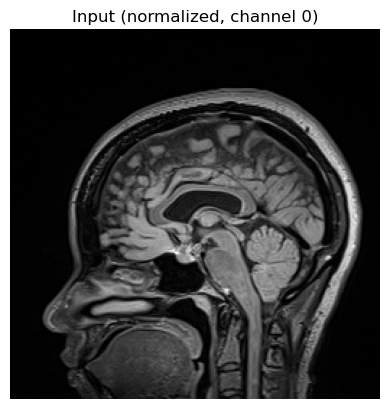

In [5]:
rgb, info = load_file(INPUT_PATH)
print(info)
print("Prepared image for SAM:", rgb.shape, rgb.dtype)

# Display the (normalized) grayscale image from channel 0
plt.figure()
plt.imshow(rgb[..., 0], cmap='gray')
plt.title('Input (normalized, channel 0)')
plt.axis('off')
plt.show()


Current BOX: None
Current POINT: None
Tip: Use the buttons above to set prompts from image clicks.


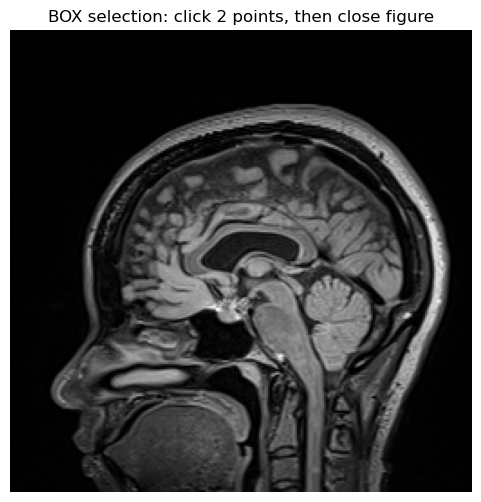

In [ ]:
# Inline click interaction using ipycanvas (run after Cell 9: image load/preview)
# This avoids matplotlib backend issues and captures clicks directly on the displayed image.

from ipycanvas import Canvas
import ipywidgets as widgets
from IPython.display import display

if 'rgb' not in globals() or rgb is None:
    print('[warn] rgb is not ready. Run Cell 9 first (Load input and visualize).')
else:
    CLICK_PROMPT_MODE = None
    CLICK_PROMPT_POINTS = []
    CLICK_PROMPT_OUTPUT = widgets.Output()

    CANVAS_W = int(rgb.shape[1])
    CANVAS_H = int(rgb.shape[0])
    PROMPT_CANVAS = Canvas(width=CANVAS_W, height=CANVAS_H)
    PROMPT_CANVAS.layout.border = '1px solid #999'

    def _rgba_from_rgb(image_rgb):
        alpha = np.full((image_rgb.shape[0], image_rgb.shape[1], 1), 255, dtype=np.uint8)
        return np.concatenate([image_rgb.astype(np.uint8), alpha], axis=-1)

    def _sync_to_main_widget():
        if 'SAMRI_PROMPT_WIDGET' not in globals() or SAMRI_PROMPT_WIDGET is None:
            return

        if BOX is not None:
            SAMRI_PROMPT_WIDGET['box_x1'].value = int(BOX[0])
            SAMRI_PROMPT_WIDGET['box_y1'].value = int(BOX[1])
            SAMRI_PROMPT_WIDGET['box_x2'].value = int(BOX[2])
            SAMRI_PROMPT_WIDGET['box_y2'].value = int(BOX[3])

        if POINT is not None and len(POINT) > 0:
            SAMRI_PROMPT_WIDGET['use_point'].value = True
            SAMRI_PROMPT_WIDGET['pt_x'].value = int(POINT[0][0])
            SAMRI_PROMPT_WIDGET['pt_y'].value = int(POINT[0][1])
        else:
            SAMRI_PROMPT_WIDGET['use_point'].value = False

    def _redraw_canvas():
        PROMPT_CANVAS.clear()
        PROMPT_CANVAS.put_image_data(_rgba_from_rgb(rgb), 0, 0)

        if BOX is not None:
            x1, y1, x2, y2 = BOX
            PROMPT_CANVAS.stroke_style = 'yellow'
            PROMPT_CANVAS.line_width = 2
            PROMPT_CANVAS.stroke_rect(x1, y1, x2 - x1, y2 - y1)

        if POINT is not None:
            for px, py in POINT:
                PROMPT_CANVAS.fill_style = 'cyan'
                PROMPT_CANVAS.fill_circle(px, py, 4)

        if CLICK_PROMPT_MODE == 'box':
            PROMPT_CANVAS.fill_style = 'rgba(255, 255, 0, 0.8)'
            PROMPT_CANVAS.fill_text('BOX mode: click 2 points', 8, 16)
        elif CLICK_PROMPT_MODE == 'point':
            PROMPT_CANVAS.fill_style = 'rgba(0, 255, 255, 0.8)'
            PROMPT_CANVAS.fill_text('POINT mode: click 1 point', 8, 16)
        else:
            PROMPT_CANVAS.fill_style = 'rgba(255, 255, 255, 0.8)'
            PROMPT_CANVAS.fill_text('Choose a mode and click on the image', 8, 16)

    def _set_mode_box(_):
        global CLICK_PROMPT_MODE, CLICK_PROMPT_POINTS
        CLICK_PROMPT_MODE = 'box'
        CLICK_PROMPT_POINTS = []
        with CLICK_PROMPT_OUTPUT:
            CLICK_PROMPT_OUTPUT.clear_output(wait=True)
            print('BOX mode: click two corners directly on the image.')
            print('First click any corner, second click the opposite corner.')
        _redraw_canvas()

    def _set_mode_point(_):
        global CLICK_PROMPT_MODE, CLICK_PROMPT_POINTS
        CLICK_PROMPT_MODE = 'point'
        CLICK_PROMPT_POINTS = []
        with CLICK_PROMPT_OUTPUT:
            CLICK_PROMPT_OUTPUT.clear_output(wait=True)
            print('POINT mode: click once on the foreground region.')
        _redraw_canvas()

    def _clear_prompts(_):
        global BOX, POINT, CLICK_PROMPT_MODE, CLICK_PROMPT_POINTS
        BOX, POINT = None, None
        CLICK_PROMPT_MODE = None
        CLICK_PROMPT_POINTS = []
        _sync_to_main_widget()
        with CLICK_PROMPT_OUTPUT:
            CLICK_PROMPT_OUTPUT.clear_output(wait=True)
            print('Cleared BOX and POINT.')
        _redraw_canvas()

    def _handle_mouse_down(x, y):
        global BOX, POINT, CLICK_PROMPT_POINTS

        if CLICK_PROMPT_MODE == 'box':
            CLICK_PROMPT_POINTS.append((int(round(x)), int(round(y))))
            with CLICK_PROMPT_OUTPUT:
                CLICK_PROMPT_OUTPUT.clear_output(wait=True)
                print(f'BOX click {len(CLICK_PROMPT_POINTS)}/2:', CLICK_PROMPT_POINTS[-1])

            if len(CLICK_PROMPT_POINTS) == 2:
                (x1, y1), (x2, y2) = CLICK_PROMPT_POINTS
                x_min, x_max = sorted([x1, x2])
                y_min, y_max = sorted([y1, y2])
                x_min = int(np.clip(x_min, 0, CANVAS_W - 1))
                x_max = int(np.clip(x_max, 0, CANVAS_W - 1))
                y_min = int(np.clip(y_min, 0, CANVAS_H - 1))
                y_max = int(np.clip(y_max, 0, CANVAS_H - 1))
                BOX = [x_min, y_min, x_max, y_max]
                CLICK_PROMPT_POINTS = []
                _sync_to_main_widget()
                with CLICK_PROMPT_OUTPUT:
                    print('BOX set from clicks:', BOX)
                    print('Synced to SAMRI_PROMPT_WIDGET.')
                _redraw_canvas()

        elif CLICK_PROMPT_MODE == 'point':
            px = int(np.clip(int(round(x)), 0, CANVAS_W - 1))
            py = int(np.clip(int(round(y)), 0, CANVAS_H - 1))
            POINT = [[px, py]]
            _sync_to_main_widget()
            with CLICK_PROMPT_OUTPUT:
                CLICK_PROMPT_OUTPUT.clear_output(wait=True)
                print('POINT set from click:', POINT)
                print('Synced to SAMRI_PROMPT_WIDGET.')
            _redraw_canvas()

    PROMPT_CANVAS.on_mouse_down(_handle_mouse_down)

    START_BOX_BTN = widgets.Button(description='Start BOX click mode', button_style='success')
    START_POINT_BTN = widgets.Button(description='Start POINT click mode', button_style='info')
    CLEAR_BTN = widgets.Button(description='Clear BOX/POINT', button_style='warning')
    START_BOX_BTN.on_click(_set_mode_box)
    START_POINT_BTN.on_click(_set_mode_point)
    CLEAR_BTN.on_click(_clear_prompts)

    display(widgets.VBox([
        widgets.HTML('<b>Click Prompt Tools</b>'),
        widgets.HBox([START_BOX_BTN, START_POINT_BTN, CLEAR_BTN]),
        PROMPT_CANVAS,
        CLICK_PROMPT_OUTPUT,
    ]))

    _redraw_canvas()
    print('Click interaction is ready on the image canvas above.')
    print('Current BOX:', BOX)
    print('Current POINT:', POINT)
    print('Use the buttons to choose BOX or POINT mode, then click on the image itself.')

## 2.5 Click prompt tools (after image load)
Run this section **after Cell 9** so `rgb` is available.

- Click **Click BOX (2 points)** to pick two corners on the displayed image.
- Click **Click POINT (1 point)** to set a foreground point.
- Values are synced to `SAMRI_PROMPT_WIDGET` automatically.
- If click capture is unavailable in your current backend, use `SAMRI_PROMPT_WIDGET` fields manually.

## 3. Load model
Initialize the SAM/SAMRI model and the predictor. If the package or checkpoint are missing, you'll see a helpful error message.

In [7]:
try:
    from segment_anything import sam_model_registry, SamPredictor
except Exception as e:
    raise RuntimeError("segment_anything is not installed in this environment.") from e

def load_sam_model(checkpoint: str, model_type: str = "vit_b", device: str = "cuda"):
    key = "vit_b" if model_type.lower() in ("vit_b", "samri") else "vit_h"
    model = sam_model_registry[key](checkpoint=checkpoint)
    model = model.to(device)
    model.eval()
    return model

print("Loading model...")
model = load_sam_model(CHECKPOINT, model_type=MODEL_TYPE, device=DEVICE)
predictor = SamPredictor(model)
print("Model ready.")


Loading model...
[Warning] torch.load failed (Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.); retrying with map_location('mps').
Model ready.


## 4. Run prediction
This cell runs the predictor using your optional **box**/**point** prompts. If no prompts are provided, it uses a full-image box. The output mask has shape `1×H×W` (binary).

In [8]:
H, W, _ = rgb.shape
predictor.set_image(rgb)

point_coords = None
point_labels = None
if POINT is not None:
    point_coords = np.array(POINT, dtype=np.float32)
    point_labels = np.array([1], dtype=np.int32)

box_arr = None
if BOX is not None:
    box_arr = np.array(BOX, dtype=np.float32)[None, :]

pred_masks, _, _ = predictor.predict(
    point_coords=point_coords,
    point_labels=point_labels,
    box=box_arr,
    multimask_output=False,
)

if pred_masks.ndim == 2:
    pred_1hw = pred_masks[None, ...]
else:
    pred_1hw = pred_masks[:1, ...]
print("Prediction mask shape:", pred_1hw.shape, pred_1hw.dtype)


Prediction mask shape: (1, 256, 256) bool


## 5. Visualize prediction
Preview the predicted mask (grayscale), and also show a quick overlay on the input for sanity check.

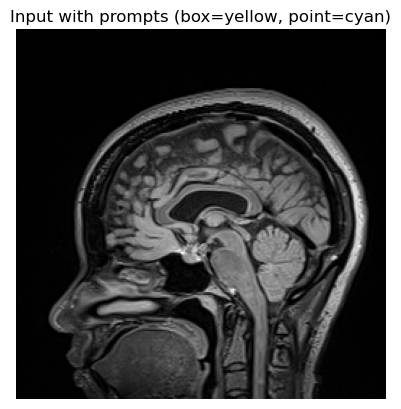

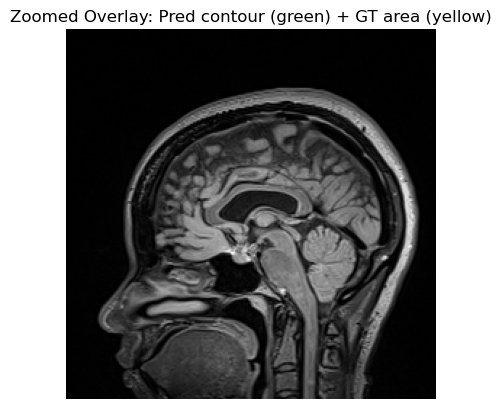

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

# --- prepare arrays ---
H, W, _ = rgb.shape
pred_hw = pred_1hw.reshape(H, W).astype(bool)

# Handle ground truth
gt_hw = None
if 'mask' in globals() and mask is not None:
    gt = mask
elif 'gt' in globals() and gt is not None:
    gt = gt
else:
    gt = None

if gt is not None:
    gt = np.asarray(gt)
    if gt.ndim == 3 and gt.shape[0] == 1:      # (1,H,W)
        gt_hw = gt[0].astype(bool)
    elif gt.ndim == 2 and gt.shape == (H, W):  # (H,W)
        gt_hw = gt.astype(bool)
    elif gt.ndim == 3 and gt.shape[-1] == 1:   # (H,W,1)
        gt_hw = gt[..., 0].astype(bool)
    else:
        print(f"[warn] GT mask has unexpected shape {gt.shape}; skipping GT overlay.")
        gt_hw = None

# ============================================================
# 1) Image with prompts (box + point)
# ============================================================
fig, ax = plt.subplots()
ax.imshow(rgb[..., 0], cmap='gray')

if 'BOX' in globals() and BOX is not None:
    x1, y1, x2, y2 = BOX
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                         fill=False, linewidth=2, edgecolor='yellow')
    ax.add_patch(rect)
    ax.text(x1, max(0, y1 - 5), "BOX", color='yellow', fontsize=9, va='bottom')

if 'POINT' in globals() and POINT is not None:
    for i in range(len(POINT)):
        ax.scatter([POINT[i][0]], [POINT[i][1]], s=60, c='cyan', marker='x', linewidths=2)
        ax.text(POINT[i][0] + 3, POINT[i][1] + 3, "POINT", color='cyan', fontsize=9, va='bottom')

ax.set_title("Input with prompts (box=yellow, point=cyan)")
ax.axis('off')
plt.show()

# ============================================================
# 2) Overlay: predicted contour + GT yellow area (zoomed)
# ============================================================
fig, ax = plt.subplots()
ax.imshow(rgb[..., 0], cmap='gray')

# Draw ground truth area (yellow fill)
if gt is not None and gt.any():
    ax.imshow(gt, cmap='gray', alpha=0.5, interpolation='none')

# Draw predicted contour (lime)
contours = measure.find_contours(pred_hw.astype(float), level=0.5)
for c in contours:
    ax.plot(c[:, 1], c[:, 0], color='lime', linewidth=2)

# Compute zoom region based on BOX (or predicted mask if BOX is None)
if 'BOX' in globals() and BOX is not None:
    x1, y1, x2, y2 = BOX
else:
    # fallback: compute bbox from predicted mask
    ys, xs = np.nonzero(pred_hw)
    if len(xs) > 0 and len(ys) > 0:
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()
    else:
        # fallback to full image if empty
        x1, y1, x2, y2 = 0, 0, rgb.shape[1]-1, rgb.shape[0]-1

# Expand box by 50%
expand_ratio = 0.5
w_box = x2 - x1
h_box = y2 - y1
dx = w_box * expand_ratio / 2
dy = h_box * expand_ratio / 2

x1_exp = max(0, x1 - dx)
x2_exp = min(rgb.shape[1] - 1, x2 + dx)
y1_exp = max(0, y1 - dy)
y2_exp = min(rgb.shape[0] - 1, y2 + dy)

# Apply zoom to axes
ax.set_xlim(x1_exp, x2_exp)
ax.set_ylim(y2_exp, y1_exp)  # inverted y-axis in imshow

# Add titles and aesthetics
ax.set_title("Zoomed Overlay: Pred contour (green) + GT area (yellow)")
ax.axis('off')
plt.show()



## 6. Save outputs (.nii.gz and optional PNG)
The `.nii.gz` is saved with shape `1×H×W` using an identity affine. The PNG is a single-channel grayscale image (`H×W`).

In [10]:
nii_path = save_mask_nii_gz(OUTPUT_DIR, BASE, pred_1hw, affine=np.eye(4), header=None)
print("Saved NIfTI:", nii_path)
png_path = None
if SAVE_PNG:
    png_path = save_mask_png(OUTPUT_DIR, BASE, pred_1hw)
    print("Saved PNG:", png_path)
print("Done.")


Saved NIfTI: /Users/benjaminbartelle/Pictures/MRSI_anatomy/MRSI/RMS01_V3/ANATOMY/RMS01_MPRAGE_seg_.nii.gz
Saved PNG: /Users/benjaminbartelle/Pictures/MRSI_anatomy/MRSI/RMS01_V3/ANATOMY/RMS01_MPRAGE_seg_.png
Done.
